In [1]:
!pip install kagglehub


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import kagglehub

path = kagglehub.dataset_download(
    "goutham1208/multi-noises-for-image-denoising"
)

print("Dataset Path:", path)

c:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 355M/355M [02:43<00:00, 2.27MB/s] 

Extracting files...


Dataset Path: C:\Users\Asus\.cache\kagglehub\datasets\goutham1208\multi-noises-for-image-denoising\versions\1


In [18]:
base_path = path + "/dataset"
sp_path = base_path + "/noises"

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

In [8]:
print(os.listdir(base_path + "/noises"))

['gaussian', 'jpeg', 'multiplicative', 'poisson', 'quantization', 'salt_and_pepper', 'speckle']


In [9]:
def preprocessing(img):


    img = cv2.resize(img, (256,256))


    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    return gray

In [10]:
def filtering(gray):

    # Median Filter
    median = cv2.medianBlur(gray, 3)

    # Gaussian Blur
    clean = cv2.GaussianBlur(median, (3,3), 0)

    # CLAHE Enhancement
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    enhanced = clahe.apply(clean)

    # Sharpen
    blur = cv2.GaussianBlur(enhanced, (0,0), 3)

    sharp = cv2.addWeighted(
        enhanced,
        1.6,
        blur,
        -0.6,
        0

    )

    return clean, enhanced, sharp

In [11]:
def edge_detection(sharp):

    # Sobel
    sobelx = cv2.Sobel(
        sharp,
        cv2.CV_64F,
        1,
        0,
        ksize=3
    )

    sobely = cv2.Sobel(
        sharp,
        cv2.CV_64F,
        0,
        1,
        ksize=3
    )

    sobel = cv2.magnitude(sobelx, sobely)

    sobel = cv2.normalize(
        sobel,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    # Canny
    blur2 = cv2.GaussianBlur(sharp, (5,5), 0)

    canny = cv2.Canny(
        blur2,
        80,
        150
    )

    return sobel, canny

In [12]:
def segmentation(sharp):

    edges = cv2.Canny(sharp, 80, 150)

    kernel = np.ones((3,3), np.uint8)

    seg = cv2.dilate(edges, kernel, iterations=1)

    seg = cv2.morphologyEx(
        seg,
        cv2.MORPH_CLOSE,
        kernel
    )

    seg = cv2.dilate(seg, kernel, iterations=2)

    seg = cv2.medianBlur(seg, 5)

    return seg

In [13]:
def full_pipeline(img):

    # Preprocessing
    gray = preprocessing(img)

    # Filtering
    clean, enhanced, sharp = filtering(gray)

    # Edge Detection
    sobel, canny = edge_detection(sharp)    # sopel  canny

    # Segmentation
    seg = segmentation(sharp)

    return gray, enhanced, clean, sharp, sobel, canny, seg

In [14]:
def overlay_edges(img, canny):

    img = cv2.resize(img, (256,256))

    edges_colored = np.zeros_like(img)    #black pic

    edges_colored[canny > 0] = [0,0,255]  # يخلي لون البكسل بالاحمر

    overlay = cv2.addWeighted(    #merge 2 layers
        img,
        0.9,
        edges_colored,
        1,
        0
    )

    return overlay

In [21]:
def show_result(path):

    image_extensions = [".jpg", ".jpeg", ".png", ".bmp"]

    image_files = []

    for root, dirs, files in os.walk(path):
        for file in files:
            if file.lower().endswith(tuple(image_extensions)):
                image_files.append(os.path.join(root, file))

    if len(image_files) == 0:
        print("No image files found.")
        return

    img_path = random.choice(image_files)

    img = cv2.imread(img_path)

    if img is None:
        print("OpenCV could not read this image:")
        print(img_path)
        return

    gray, enhanced, clean, sharp, sobel, canny, seg = full_pipeline(img)

    overlay = overlay_edges(img, canny)

    titles = [
        "Gray",
        "Enhanced",
        "Filtered",
        "Sharpen",
        "Sobel",
        "Canny",
        "Segment",
        "Overlay"
    ]

    images = [
        gray,
        enhanced,
        clean,
        sharp,
        sobel,
        canny,
        seg,
        cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
    ]

    plt.figure(figsize=(14, 10))

    for i in range(8):

        plt.subplot(3, 3, i + 1)

        if i == 7:
            plt.imshow(images[i])
        else:
            plt.imshow(images[i], cmap="gray")

        plt.title(titles[i])
        plt.axis("off")

    plt.suptitle("FINAL IMAGE PROCESSING PIPELINE")
    plt.show()

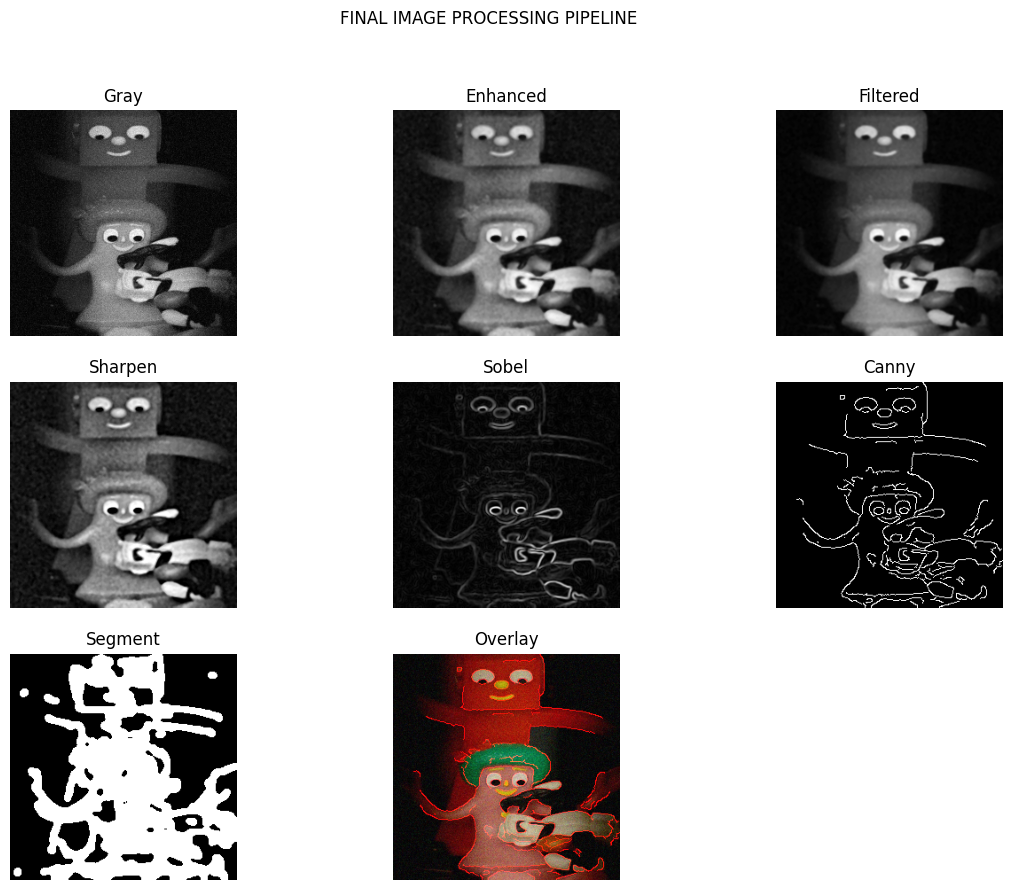

In [25]:
sp_path = base_path + "/noises"
show_result(sp_path)